# Fire-product comparison — run & inspect

This notebook drives `peatfire.fire_products_comparison`

## The data-transformation pipeline (one worked example: MCD64A1, 2017)


Key invariants:
- **Analysis CRS is always EPSG:5070** (equal-area) for area and grid comparison; the AOI's CRS is only a clip mask.
- The **common grid** (default 500 m, `how="max"` = "any sub-cell burn lights the cell") removes resolution as a confound.
- **Annual mode** ORs a product's monthly files into one yearly mask; **monthly mode** keeps each month separate and drops annual-only products.

Run the cells top to bottom. Each prints/plots the intermediate object it just made.

## 0. Setup & area of interest (AOI)

In [116]:
%load_ext autoreload
%autoreload 2

import geopandas as gpd
import matplotlib.pyplot as plt

from peatfire import data_path
from peatfire.preproc import clip_raster_to_mask, clip_vector_to_mask
from peatfire.fire_products_comparison import (
    FIRE_PRODUCTS, list_products, get_spec, load_standardized,
    build_common_grid, to_common_grid, burned_area_km2,
    annual_burned_area_series, stack_on_common_grid, agreement_matrix,
    period_totals_series, product_pair_scatter, total_least_squares, rmse,
    compare_fire_products,
    set_fire_style, plot_annual_series, plot_agreement_heatmap,
    plot_overlay_map, plot_product_scatter, plot_temporal_heatmap,
    plot_consensus_map, plot_raster_map
)

import rioxarray

set_fire_style()

# AOI: swap this path for NC peatlands / non-peatlands later -- nothing else changes.
aoi_nc = gpd.read_file(data_path("processed", "boundaries", "nc_boundary.gpkg"))
aoi_nc_peat = gpd.read_file(data_path("processed", "peat_extent", "nc_peatlands_aoi.gpkg"))
histosol = rioxarray.open_rasterio(data_path("processed", "peat_extent", "conus_histosol_major_percentage_nc.tif"), masked=True)
factor = 10
coarse_histosol = histosol.squeeze().coarsen(x=factor, y=factor, boundary='trim').mean() # build a coarser histosol map for plotting - DO NOT USE THIS FOR ANALYSES

# set which aoi you want to run fire analyses for
aoi = aoi_nc_peat

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


make nc peat extent and histosol % plot

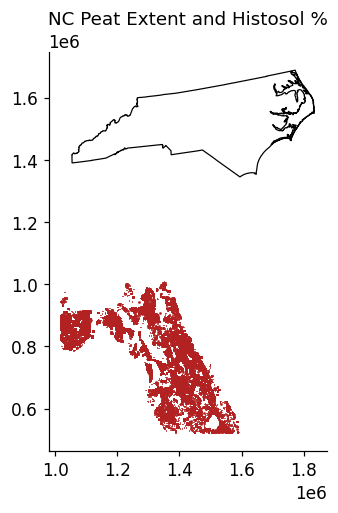

In [ ]:
# reproject vectors to match the raster so the layers align
plot_crs = coarse_histosol.rio.crs
aoi_nc = aoi_nc.to_crs(plot_crs)
aoi_nc_peat = aoi_nc_peat.to_crs(plot_crs)
test = test.to_crs(plot_crs)

fig, ax = plt.subplots()

# plot raster first as the bottom layer, squeeze() drops the single band dim so .plot() renders a 2d image instead of erroring on the band axis
coarse_histosol.plot.imshow(
    ax=ax, cmap='Greens', add_colorbar=True, vmin=0, vmax=100,
    cbar_kwargs={'label': 'Histosol major %'}
)

# boundaries on top, no fill so the raster shows thru
aoi_nc.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8)
aoi_nc_peat.plot(ax=ax, facecolor='none', edgecolor='firebrick', linewidth=1, alpha=0.3)
ax.set_title('NC Peat Extent and Histosol %')
plt.show()

## 1. What products are registered, and which have data on disk?

The registry is the single source of truth. `directory` resolves each product's folder via `data_path`.

In [57]:
import pandas as pd
rows = []
for name in list_products():
    s = get_spec(name)
    n_files = len(sorted(s.directory.glob(s.glob))) if s.directory.exists() else 0
    rows.append({"product": name, "family": s.family, "res_m": s.native_res_m,
                 "temporal": s.temporal, "monthly": s.month_parser is not None,
                 "dir_exists": s.directory.exists(), "n_files": n_files,
                 "directory": str(s.directory)})
pd.DataFrame(rows).set_index("product")

,family,res_m,temporal,monthly,dir_exists,n_files,directory
product,,,,,,,
MCD64A1,burned_area,500.0,monthly,True,True,305,/Users/jinjiang-macair/Library/CloudStorage/On...
GABAM,burned_area,30.0,annual,False,True,29,/Users/jinjiang-macair/Library/CloudStorage/On...
FireCCI51,burned_area,250.0,monthly,True,True,240,/Users/jinjiang-macair/Library/CloudStorage/On...
FireCCIS311,burned_area,300.0,monthly,True,True,72,/Users/jinjiang-macair/Library/CloudStorage/On...
VIIRS,occurrence,375.0,events,False,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
SE_FireMap,severity,30.0,annual,False,True,23,/Users/jinjiang-macair/Library/CloudStorage/On...
MOSEV,severity,500.0,monthly,True,True,236,/Users/jinjiang-macair/Library/CloudStorage/On...
MTBS,severity,30.0,annual,False,True,40,/Users/jinjiang-macair/Library/CloudStorage/On...
USGS_BA,burned_area,30.0,annual,False,False,0,/Users/jinjiang-macair/Library/CloudStorage/On...


## 2. Load ONE product for ONE year, and inspect every sub-step

We trace MCD64A1 / 2017. First the raw clip (note it keeps a singleton `band` dim), then the
standardized annual mask the toolkit actually uses (band squeezed, months OR'd).

In [58]:
product, year = "MOSEV", 2017
spec = get_spec(product)

# (a) the monthly files the loader will group for this year
files = sorted(spec.directory.glob(spec.glob))
files_2017 = [f for f in files if spec.year_parser(f) == year]
print(f"{product}: {len(files_2017)} monthly files for {year}")
for f in files_2017[:3]:
    print("   ", f.name, "-> month", spec.month_parser(f))

# (b) raw clip of a single month (in memory). Still has a band dimension.
one = clip_raster_to_mask(files_2017[0], aoi)
print("\nsingle clipped month -> dims:", dict(one.sizes), "| CRS:", one.rio.crs)

MOSEV: 12 monthly files for 2017
    MOSEV_A2017001_nc.tif -> month 1
    MOSEV_A2017032_nc.tif -> month 2
    MOSEV_A2017060_nc.tif -> month 3

single clipped month -> dims: {'band': 7, 'y': 635, 'x': 1223} | CRS: PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


annual mask name : MOSEV
dims             : {'y': 635, 'x': 1223}
CRS              : PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]] (native sinusoidal)
burned pixels    : 0


/Users/jinjiang-macair/anaconda3/envs/peat_fire_stanback/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:268: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


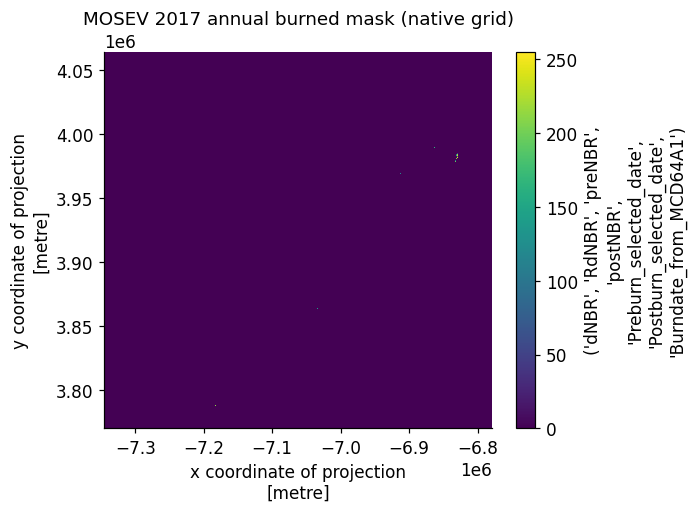

In [59]:
# (c) the standardized ANNUAL mask (band squeezed, 12 months OR'd, True=burned)
mask = load_standardized(product, year, aoi)
print("annual mask name :", mask.name)
print("dims             :", dict(mask.sizes))
print("CRS              :", mask.rio.crs, "(native sinusoidal)")
print("burned pixels    :", int((mask.values == True).sum()))
mask.astype("uint8").plot(); plt.title(f"{product} {year} annual burned mask (native grid)"); plt.show()

## 3. The common grid (the resolution-confound fix)

`build_common_grid` makes an empty EPSG:5070 reference grid over the AOI; `to_common_grid` warps any
product onto it with `how="max"`. Every product is matched to THIS grid, so none is privileged.

common grid CRS  : EPSG:5070
common grid shape: {'y': 673, 'x': 1290}
pixel size (m)   : (500.0, -500.0)

mask on common grid -> dims: {'y': 673, 'x': 1290} | CRS: EPSG:5070


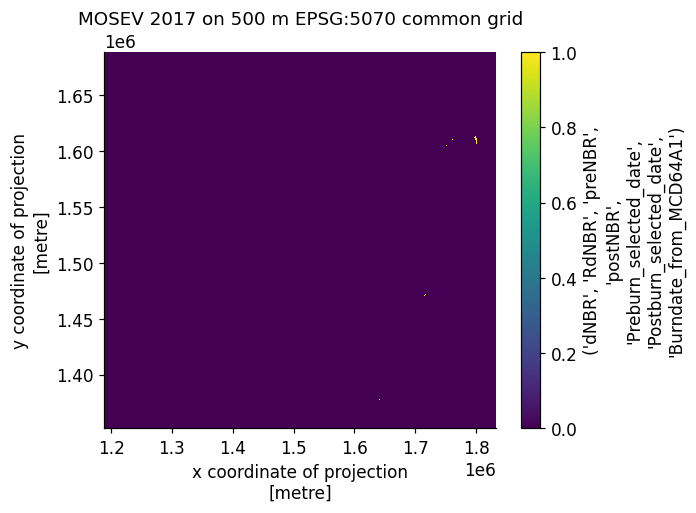

In [60]:
grid = build_common_grid(aoi, res_m=500.0)
print("common grid CRS  :", grid.rio.crs)
print("common grid shape:", dict(grid.sizes))
print("pixel size (m)   :", grid.rio.resolution())

mask_cg = to_common_grid(mask.astype("float32"), grid, how="max") > 0
print("\nmask on common grid -> dims:", dict(mask_cg.sizes), "| CRS:", mask_cg.rio.crs)
mask_cg.astype("uint8").plot(); plt.title(f"{product} {year} on 500 m EPSG:5070 common grid"); plt.show()

## 4. Annual burned-area series — native vs common-grid (Humber Figure 3)

`mode="native"` uses each product's own pixel area; `mode="common_grid"` puts everyone on the shared
500 m grid first. Comparing the two shows how much of any product difference is just resolution.

In [61]:
products_ba = ["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311"]   # absent ones skip with a warning
# products_ba = ["FireCCI51"]   # absent ones skip with a warning

years = range(2001, 2022)

area_native = annual_burned_area_series(products_ba, years, aoi, mode="native")
area_cg     = annual_burned_area_series(products_ba, years, aoi, mode="common_grid")
display(area_native.head())
display(area_cg.head())

,MCD64A1,MCD64A1_pct_aoi,GABAM,GABAM_pct_aoi,FireCCI51,FireCCI51_pct_aoi,FireCCIS311,FireCCIS311_pct_aoi
year,,,,,,,,
2001,3.005221,0.051546,49.4649,0.848428,3.9420,0.067614,NaN,NaN
2002,10.303616,0.176729,17.1918,0.294876,6.2604,0.107379,NaN,NaN
2003,8.371688,0.143592,24.5925,0.421814,3.0663,0.052594,NaN,NaN
2004,15.026107,0.257730,66.4056,1.138998,14.2947,0.245185,NaN,NaN
2005,1.073293,0.018409,21.1671,0.363061,26.8002,0.459681,NaN,NaN


,MCD64A1,MCD64A1_pct_aoi,GABAM,GABAM_pct_aoi,FireCCI51,FireCCI51_pct_aoi,FireCCIS311,FireCCIS311_pct_aoi
year,,,,,,,,
2001,7.75,0.132929,211.5,3.627676,9.75,0.167233,NaN,NaN
2002,18.50,0.317314,76.0,1.303562,25.00,0.428803,NaN,NaN
2003,10.75,0.184385,75.5,1.294986,10.75,0.184385,NaN,NaN
2004,25.75,0.441667,253.0,4.339489,35.50,0.608901,NaN,NaN
2005,3.25,0.055744,87.5,1.500811,50.25,0.861895,NaN,NaN


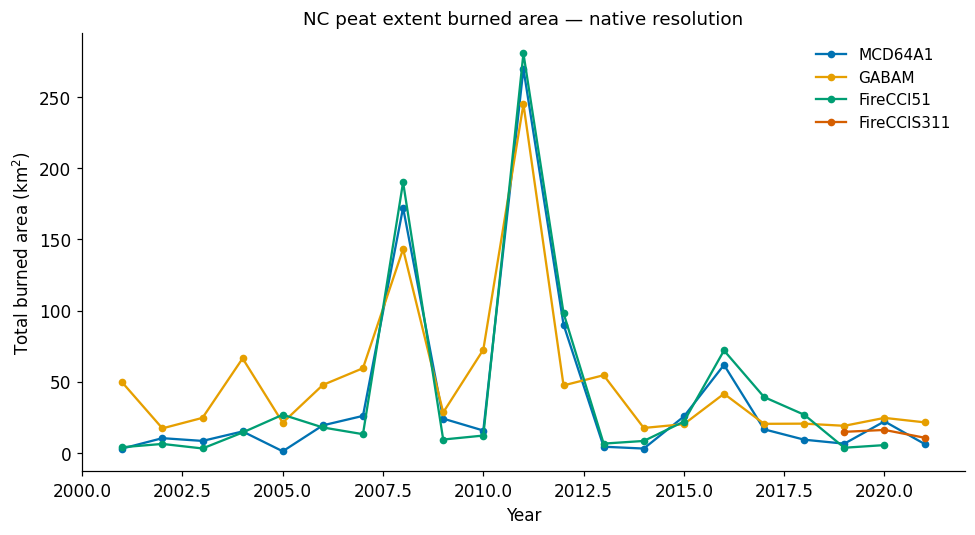

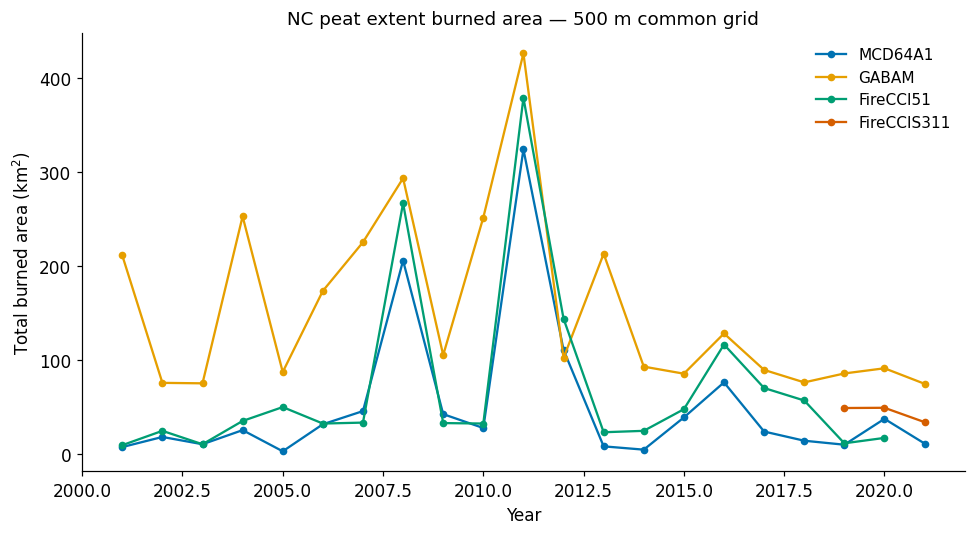

In [121]:
plot_annual_series(area_native, title="NC peat extent burned area — native resolution"); plt.show()
plot_annual_series(area_cg,     title="NC peat extent burned area — 500 m common grid"); plt.show()

viirs counts - don't run this if not including viirs

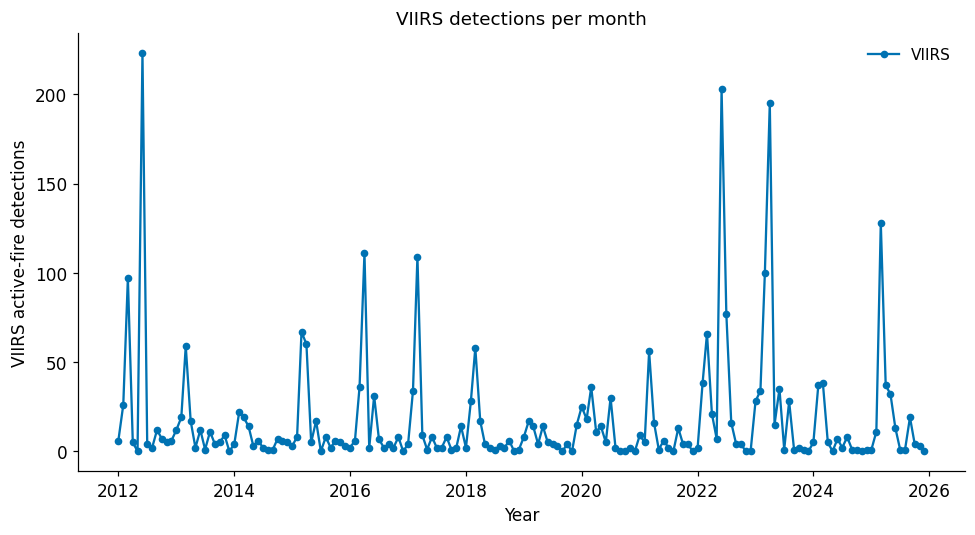

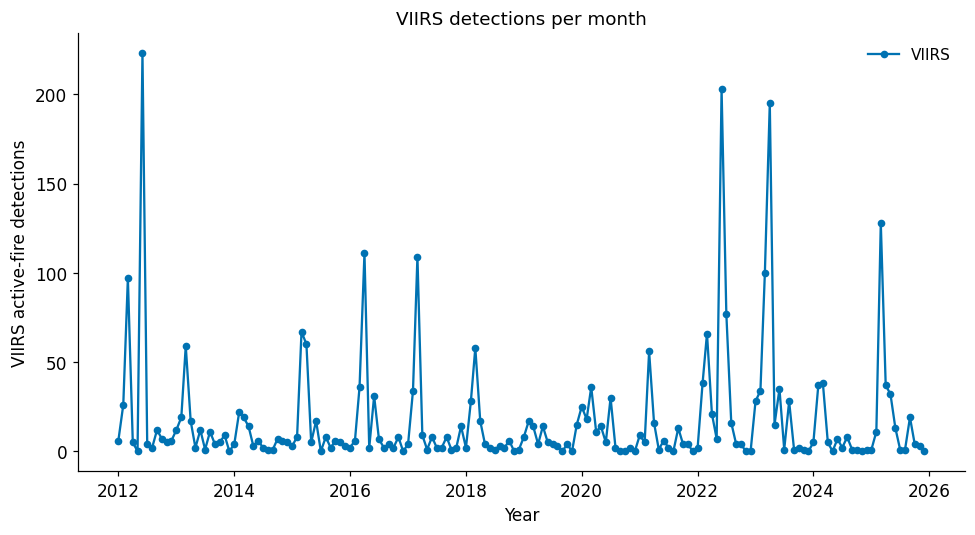

In [63]:
counts_ts = period_totals_series(["VIIRS"], range(2012, 2026), aoi, temporal_unit="month")
plot_annual_series(counts_ts, ylabel="VIIRS active-fire detections", title="VIIRS detections per month")

## 5. Agreement matrices ("confusion-matrix" heatmaps)

VIIRS is included as the independent occurrence check. Binary spatial agreement (Jaccard, kappa) and
temporal correlation of annual totals answer different questions.

In [73]:
products_all = ["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311", "VIIRS"]
# products_sev = ['SE_FireMap', 'MOSEV', 'MTBS']

jac = agreement_matrix(products_all, years, aoi, method="jaccard", pooling="cells")
kap = agreement_matrix(products_all, years, aoi, method="kappa",   pooling="cells")
cor = agreement_matrix(products_ba,  years, aoi, method="pearson", pooling="years")

if products_sev:
    years = range(2000, 2021)
    spearman_cor = agreement_matrix(products_sev, years, aoi, method="spearman", pooling="cells")
    display(spearman_cor.round(2))
else:
    display(jac.round(2)); display(cor.round(2))

,SE_FireMap,MOSEV,MTBS
SE_FireMap,1.00,0.07,0.38
MOSEV,0.07,1.00,0.09
MTBS,0.38,0.09,1.00


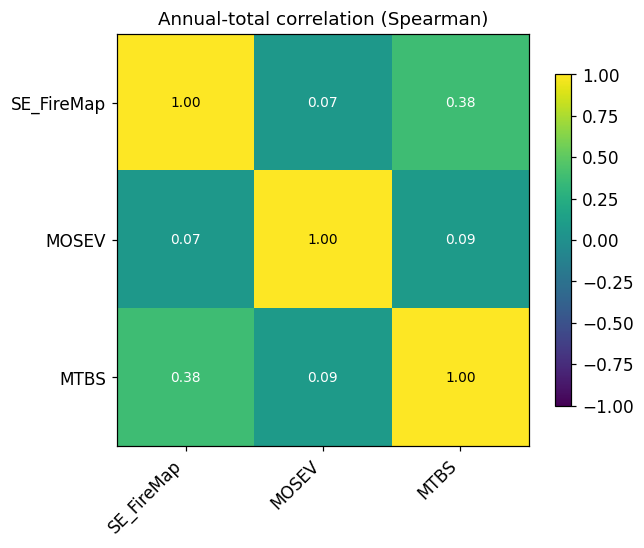

In [ ]:
if products_sev:
    plot_agreement_heatmap(spearman_cor, title="Annual-total correlation (Spearman)", vmin=-1, vmax=1); plt.show()
else:
    plot_agreement_heatmap(jac, title="Spatial agreement (Jaccard)", vmin=0, vmax=1); plt.show()
    plot_agreement_heatmap(cor, title="Annual-total correlation (Pearson)", vmin=-1, vmax=1); plt.show()

## 5b. Pairwise scatterplots — total least squares (Humber-style)

Humber compares two products at a time with **total least squares** (orthogonal regression, which
minimises perpendicular distance — right when *both* axes have error) and reports **RMSE** against the
**y = x** line. Each scatter point is one common-grid cell (our per-spatial-unit analogue of their per-TSA
points), holding that cell's burned fraction.

`tls_slope` near 1 = the two products agree on magnitude; the `tls_slope` matrix is **asymmetric**
(entry [a, b] uses a as x, b as y). RMSE is symmetric. (TLS slope / RMSE on *totals* stay on the
burned-area products, which share km² units.)

n scatter points (cells): 860123
TLS slope, intercept: (0.19940369241838515, 0.0003664673463577383) | RMSE: 0.0297


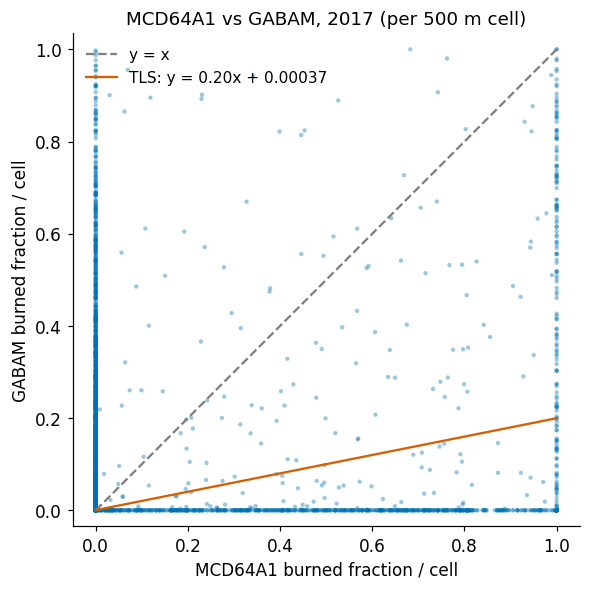

,MCD64A1,GABAM,FireCCI51,FireCCIS311
MCD64A1,1.00,14.94,1.57,-4.21
GABAM,0.07,1.00,0.41,2.17
FireCCI51,0.64,2.42,1.00,1.31
FireCCIS311,-0.24,0.46,0.76,1.00


,MCD64A1,GABAM,FireCCI51,FireCCIS311
MCD64A1,0.0,453.2,137.7,480.5
GABAM,453.2,0.0,417.2,349.2
FireCCI51,137.7,417.2,0.0,465.5
FireCCIS311,480.5,349.2,465.5,0.0


In [10]:
# scatter of two products' per-cell burned fraction in one year, with TLS + y=x
x, y = product_pair_scatter("MCD64A1", "GABAM", 2017, aoi)
print("n scatter points (cells):", x.size)
if x.size:
    print("TLS slope, intercept:", total_least_squares(x, y), "| RMSE:", round(rmse(x, y), 4))
    plot_product_scatter(
        x, y,
        xlabel="MCD64A1 burned fraction / cell",
        ylabel="GABAM burned fraction / cell",
        title="MCD64A1 vs GABAM, 2017 (per 500 m cell)",
    )
    plt.show()

# TLS-slope and RMSE matrices on per-period totals (burned-area products, km^2)
tls = agreement_matrix(products_ba, years, aoi, method="tls_slope", pooling="years")
err = agreement_matrix(products_ba, years, aoi, method="rmse",      pooling="years")
display(tls.round(2)); display(err.round(1))

## 6. Overlay map for a chosen year

`stack_on_common_grid` aligns every product for the year; `plot_overlay_map` shows where a pair agree
(1 = A only, 2 = B only, 3 = both).

In [ ]:
stack

products present in 2016 stack: ['MCD64A1', 'GABAM', 'FireCCI51']


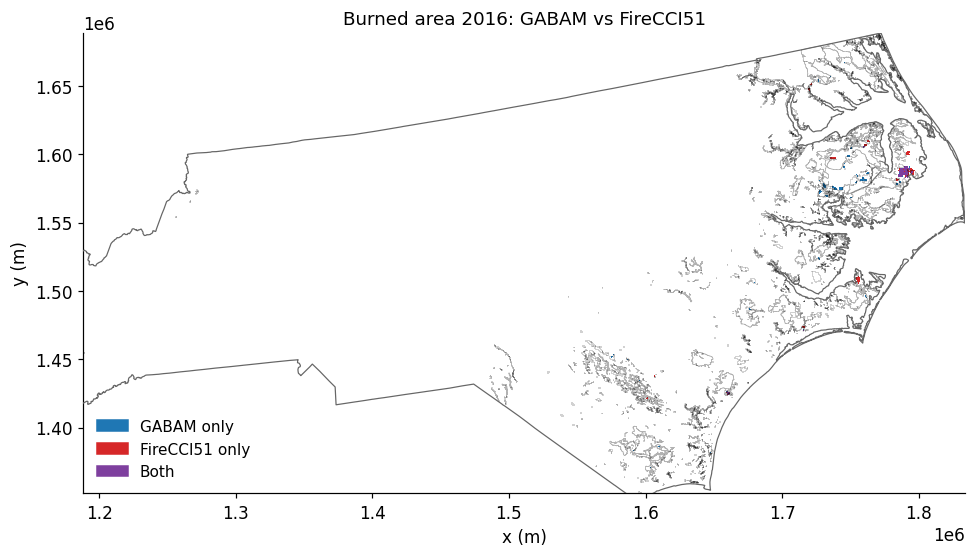

In [100]:
year = 2016
stack = stack_on_common_grid(products_ba, year, aoi, binary=True)
pair=("GABAM", "FireCCI51")
print(f"products present in {year} stack:", list(stack))
if {pair[0], pair[1]} <= set(stack):
    fig, ax = plt.subplots(figsize=(9, 6))
    plot_overlay_map(stack, aoi, year, pair=pair, ax=ax)
    
    # plot the nc overlay too if it exists
    if aoi_nc is not None:
        crs = stack[pair[0]].rio.crs           # EPSG:5070, the analysis grid CRS
        xlim, ylim = ax.get_xlim(), ax.get_ylim()   # peat-extent view set by plot_overlay_map
        aoi_nc.to_crs(crs).boundary.plot(ax=ax, color="0.4", linewidth=0.8, zorder=5)
        ax.set_xlim(xlim); ax.set_ylim(ylim)   # restore it (geopandas autoscaled to NC)

    plt.savefig(f'../outputs/figures/fire/{pair[0]}_vs_{pair[1]}_nc_peat_extent_burned_area_{year}.png')
    plt.show()

## 6b. Multi-product consensus map (all burned-area products at once)

`plot_overlay_map` compares a *pair*; `plot_consensus_map` generalises it to **all** products. Every
product is on the same EPSG:5070 common grid (via `stack_on_common_grid`), and each burned cell is
coloured by **how many** products map a burn there (1 = a single product, N = unanimous). Pass
`month=` for a single month. Bright cells are the agreement core; dim fringe cells are mapped by only
one product.

products present in 2011 stack: ['MCD64A1', 'GABAM', 'FireCCI51']


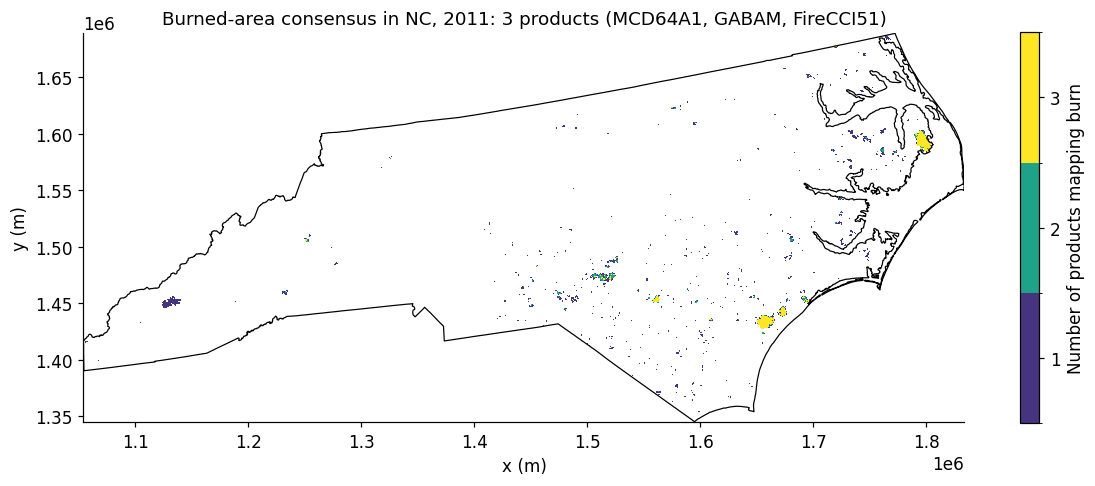

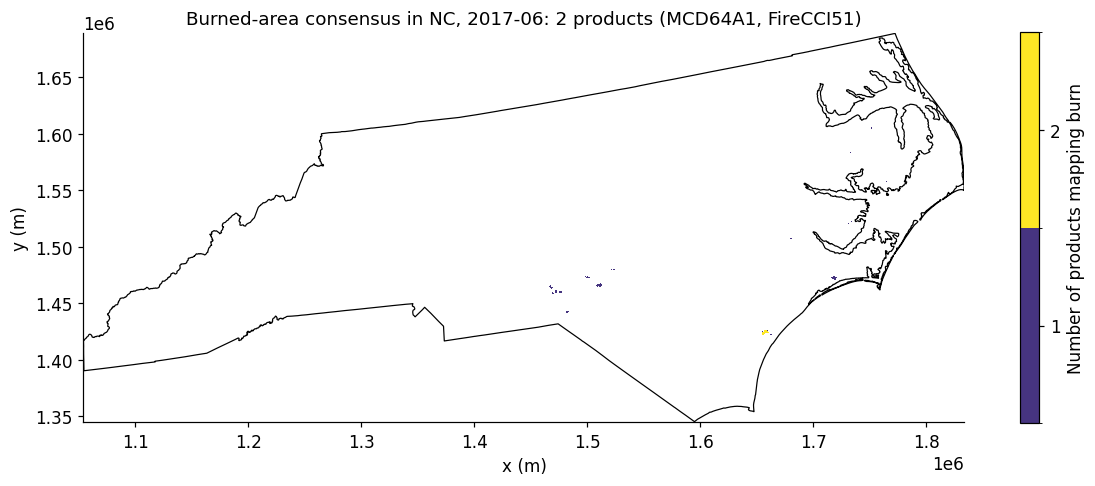

In [12]:
# all burned-area products that have data for the year, on the NC common grid
stack_2011 = stack_on_common_grid(products_ba, 2011, aoi, binary=True)
print("products present in 2011 stack:", list(stack_2011))
fig = plot_consensus_map(stack_2011, aoi, 2011)
plt.show()

# single month works too: pass month= to the stack, then to the plot
stack_2017_06 = stack_on_common_grid(products_ba, 2017, aoi, binary=True, month=6)
if stack_2017_06:
    plot_consensus_map(stack_2017_06, aoi, 2017, month=6); plt.show()

### individual severity product maps for 2017

In [117]:
year = 2016

sev_products = list_products('severity')
for prod in sev_products:
    stack = stack_on_common_grid([prod], year, aoi, binary=False)
    if prod not in stack:                      # graceful skip if not downloaded
        print(f"{prod}: no data, skipping"); continue
    sev = stack[prod]
    print(prod, "max:", float(sev.max()), "nonzero cells:", int((sev > 0).sum()))

    # severity
    fig = plot_raster_map(sev, aoi, title=f"{prod} severity {year}", aoi_context=aoi_nc)
    plt.savefig(f'../outputs/figures/fire/{prod}_{year}_nc_peat_extent_map.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

SE_FireMap max: 2.084439754486084 nonzero cells: 49
MOSEV max: 977.0105590820312 nonzero cells: 170
MTBS max: 3.0 nonzero cells: 184


occurrence map for specific year

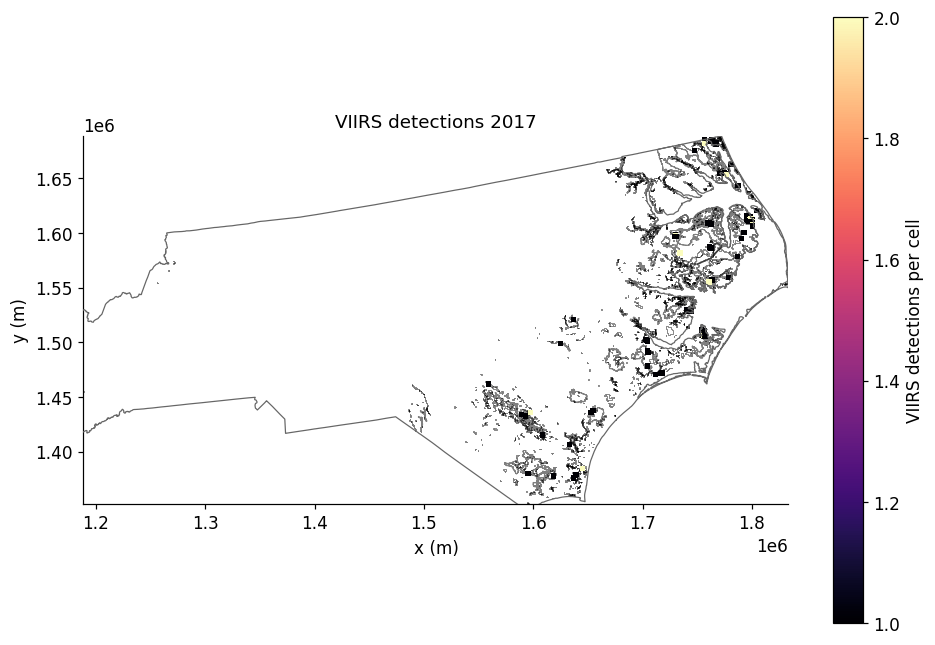

In [120]:
year = 2017

counts = stack_on_common_grid(["VIIRS"], year, aoi, binary=False)["VIIRS"]  # detections / 500 m cell

fig = plot_raster_map(counts, aoi, title=f"VIIRS detections {year}",
                      label="VIIRS detections per cell", aoi_context=aoi_nc)

plt.savefig(f'../outputs/figures/fire/viirs_{year}_nc_peat_extent_map.png')

## 7. Monthly mode

One flag: `temporal_unit="month"`. Annual-only products (GABAM, USGS_BA, ...) are dropped; the monthly
products + VIIRS remain. The series index becomes month-start Timestamps.

,MCD64A1,MCD64A1_pct_aoi,FireCCI51,FireCCI51_pct_aoi
period,,,,
2017-01-01,64.75,0.050351,0.00,0.000000
2017-02-01,52.25,0.040630,0.50,0.000389
2017-03-01,93.25,0.072513,63.25,0.049184
2017-04-01,17.00,0.013219,43.75,0.034021
2017-05-01,24.50,0.019052,39.75,0.030910
2017-06-01,29.00,0.022551,60.00,0.046657
2017-07-01,3.00,0.002333,69.00,0.053655
2017-08-01,0.00,0.000000,24.50,0.019052
2017-09-01,15.25,0.011859,50.50,0.039270


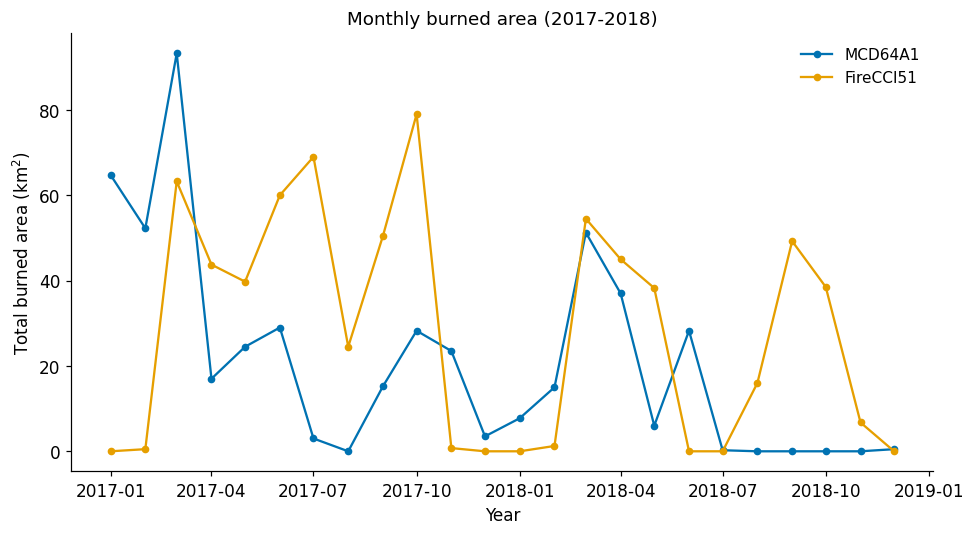

In [ ]:
area_monthly = annual_burned_area_series(
    ["MCD64A1", "FireCCI51", "FireCCIS311"], range(2017, 2019),
    aoi, mode="common_grid", temporal_unit="month",
)
display(area_monthly.head(14))
plot_annual_series(area_monthly, title="Monthly burned area (2017-2018)"); plt.show()

## 7b. Temporal heat map (Humber-style)

`period_totals_series` gives, per month, burned-area km² for each product and the VIIRS active-fire
**detection count**. `plot_temporal_heatmap` lays this out as products × time, with VIIRS as the bottom
reference row. By default each row is normalised to its own max so the *timing* is comparable across
products despite the different units — bright cells lining up vertically mean a product's burn
detections coincide with active fire.

,MCD64A1,FireCCI51,VIIRS,FireCCIS311
period,,,,
2012-01-01,23.75,0.00,178,NaN
2012-02-01,27.50,0.50,472,NaN
2012-03-01,101.75,127.25,971,NaN
2012-04-01,14.00,14.75,455,NaN
2012-05-01,14.00,36.25,319,NaN
2012-06-01,155.00,204.50,988,NaN
2012-07-01,1.00,17.25,323,NaN
2012-08-01,0.00,0.00,238,NaN
2012-09-01,15.25,39.50,465,NaN


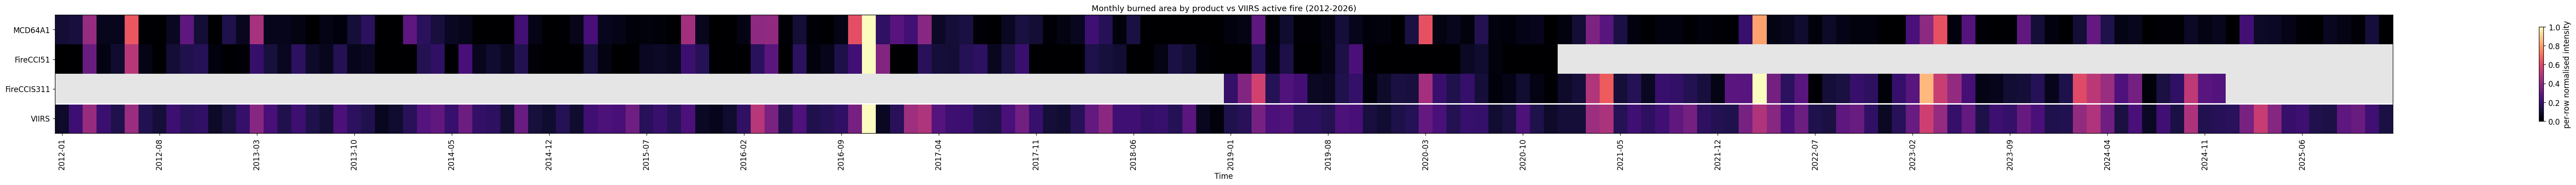

In [18]:
totals_m = period_totals_series(
    ["MCD64A1", "FireCCI51", "FireCCIS311", "VIIRS"], range(2012, 2026),
    aoi, temporal_unit="month",
)
display(totals_m.head(14))
plot_temporal_heatmap(
    totals_m, normalize="row",
    title="Monthly burned area by product vs VIIRS active fire (2012-2026)",
)
plt.show()

,MCD64A1,FireCCI51,GABAM,VIIRS,FireCCIS311
year,,,,,
2012,111.00,144.25,102.50,393,NaN
2013,8.50,23.50,213.25,151,NaN
2014,5.00,25.00,93.25,90,NaN
2015,39.25,48.00,85.75,184,NaN
2016,76.50,116.75,128.50,211,NaN
2017,24.25,70.50,89.75,194,NaN
2018,14.50,57.25,76.50,124,NaN
2019,10.25,11.75,86.00,88,49.25
2020,37.75,17.50,91.50,143,49.50


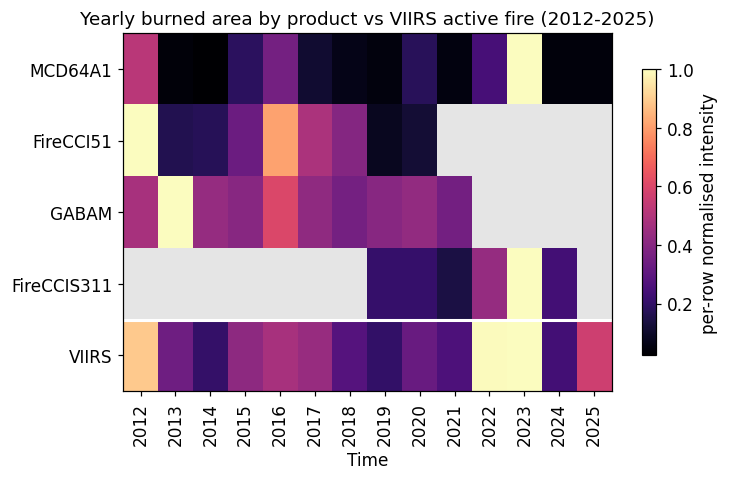

In [ ]:
products = ["MCD64A1", "FireCCI51", "FireCCIS311", "GABAM", "VIIRS"]
years = range(2012, 2026)          
temporal_unit = "year"
title = f"Yearly burned area by product vs VIIRS active fire ({years[0]}-{years[-1]})"

totals = period_totals_series(products, years, aoi, temporal_unit)
display(totals.head(14))

fig = plot_temporal_heatmap(totals, normalize="row", title=title)

products_save_str = "_".join(products)
fig.savefig(
    f"../outputs/figures/fire/{products_save_str}_{years[0]}_to_{years[-1]}_temporal_heatmap_by_{temporal_unit}_nc_peat_extent.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

## 8. One-call full comparison (writes CSVs)

`compare_fire_products` runs the whole thing and (with `out_dir`) saves every table. Point `aoi` at a
peatland shapefile later and rerun — nothing else changes.

In [ ]:
res = compare_fire_products(
    data_path("processed", "boundaries", "nc_boundary.gpkg"),
    products=["MCD64A1", "GABAM", "FireCCI51", "USGS_BA", "VIIRS"],
    years=range(2001, 2022),
    agreement_methods=("jaccard", "kappa"),
    overlay_years=[2017],
    out_dir=data_path("processed", "fire", "comparison", "nc"),
)
print("result keys:", list(res))
display(res["area_common_grid"].head())
display(res["agreement_jaccard"].round(2))

In [ ]:
# monthly full run (annual-only products auto-dropped)
res_m = compare_fire_products(
    data_path("processed", "boundaries", "nc_boundary.gpkg"),
    years=range(2017, 2019),
    temporal_unit="month",
    overlay_years=[(2017, 6)],
    out_dir=data_path("processed", "fire", "comparison", "nc_monthly"),
)
print("monthly result keys:", list(res_m))
display(res_m["area_common_grid"].head(14))

tests

In [70]:
import geopandas as gpd
for f in [data_path('raw', 'fire', 'reference', 'InterAgencyFirePerimeterHistory_All_Years_View_-104997095188071827.gpkg'), data_path('raw', 'fire', 'reference', 'Historic_Geomac_Perimeters_Combined_2000_2018_-7007592357689317076.gpkg')]:
    g = gpd.read_file(f, rows=1)
    print(f, "| CRS:", g.crs, "| cols:", list(g.columns))

/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/raw/fire/reference/InterAgencyFirePerimeterHistory_All_Years_View_-104997095188071827.gpkg | CRS: EPSG:3857 | cols: ['IRWINID', 'FORID', 'INCIDENT', 'GIS_ACRES', 'UNQE_FIRE_ID', 'DATE_CUR', 'FIRE_YEAR_INT', 'UNIT_ID', 'POO_RESP_I', 'LOCAL_NUM', 'FEATURE_CA', 'MAP_METHOD', 'COMMENTS', 'GEO_ID', 'SOURCE', 'AGENCY', 'FIRE_YEAR', 'GlobalID', 'geometry']
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/raw/fire/reference/Historic_Geomac_Perimeters_Combined_2000_2018_-7007592357689317076.gpkg | CRS: EPSG:3857 | cols: ['agency', 'comments', 'mapmethod', 'datecurrent', 'uniquefireidentifier', 'fireyear', 'incidentname', 'pooownerunit', 'perimeterdatetime', 'gisacres', 'complexname', 'firecode', 'complexparentirwinid', 'pooresponsibleunit', 'state', 'inciwebid', 'localincidentidentifier', 'irwinid', 'incomplex', 'complexfirecode', 'geometry']


/Users/jinjiang-macair/anaconda3/envs/peat_fire_stanback/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: Non-conformant content for record 1 in column datecurrent, 2018-02-14T00:00:00.0Z, successfully parsed
  return ogr_read(
